# A Simple New Benchmark for Forecasting Bond Risk Premia — replication

This notebook reproduces all tables and figures of the paper, in the order of the paper. Every table shows the
number **printed in the paper** (final version) next to the **reproduced** number, with a check mark when they agree
to the printed precision.

**Before running this notebook**, the results must be in `output/`. They are included in the package; to recompute
them (see `README.md`):

1. `python run_linear.py` — all linear models (about 10 minutes).
2. `python run_nn.py --tag n20` — the neural networks (about 13.5 hours; Tables 4–7).

This notebook only reads the stored results in `output/`; it runs in less than a minute.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))
import tables

# Which neural-network run to show (output/nn_<NN_TAG>/)
tables.NN_TAG = "n20"

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 40)

## Overview: agreement with the paper

In [2]:
tables.summary()

,statistic,match,differ,not run yet
table,,,,
Table 2,out-of-sample R2,8,0,0
Table 4,out-of-sample R2,8,0,0
Table 6,out-of-sample R2,10,0,0
Table D.1,out-of-sample R2,4,0,0
Table E.1,out-of-sample R2,8,0,0
Table F.1,out-of-sample R2,24,0,0
Table F.2,out-of-sample R2,16,0,0
Table 3,CER and Sharpe ratio,14,0,0
Table 7,CER and Sharpe ratio,20,0,0


## Section 2.1 — Yield data, transformations and yield factors

### Figure 1: Yields (left) and changes in yields (right)

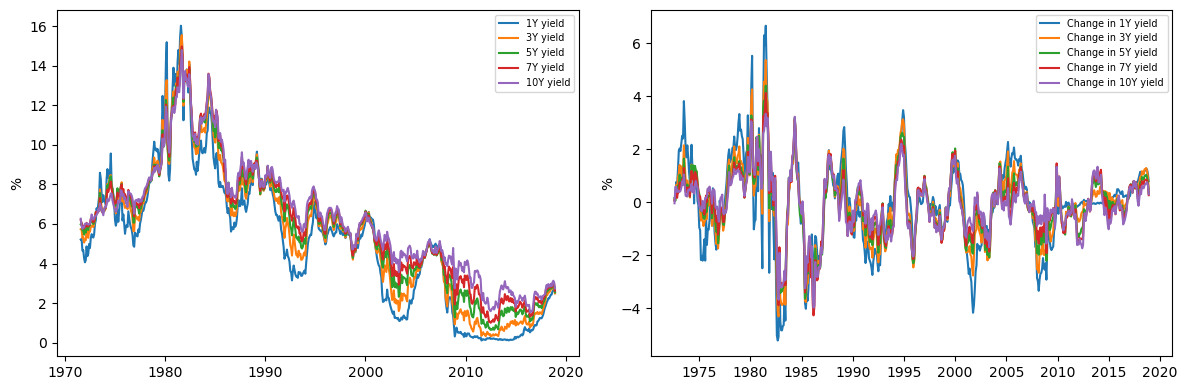

In [3]:
fig = tables.figure_1()

### Figure 2: Two- and ten-year excess returns

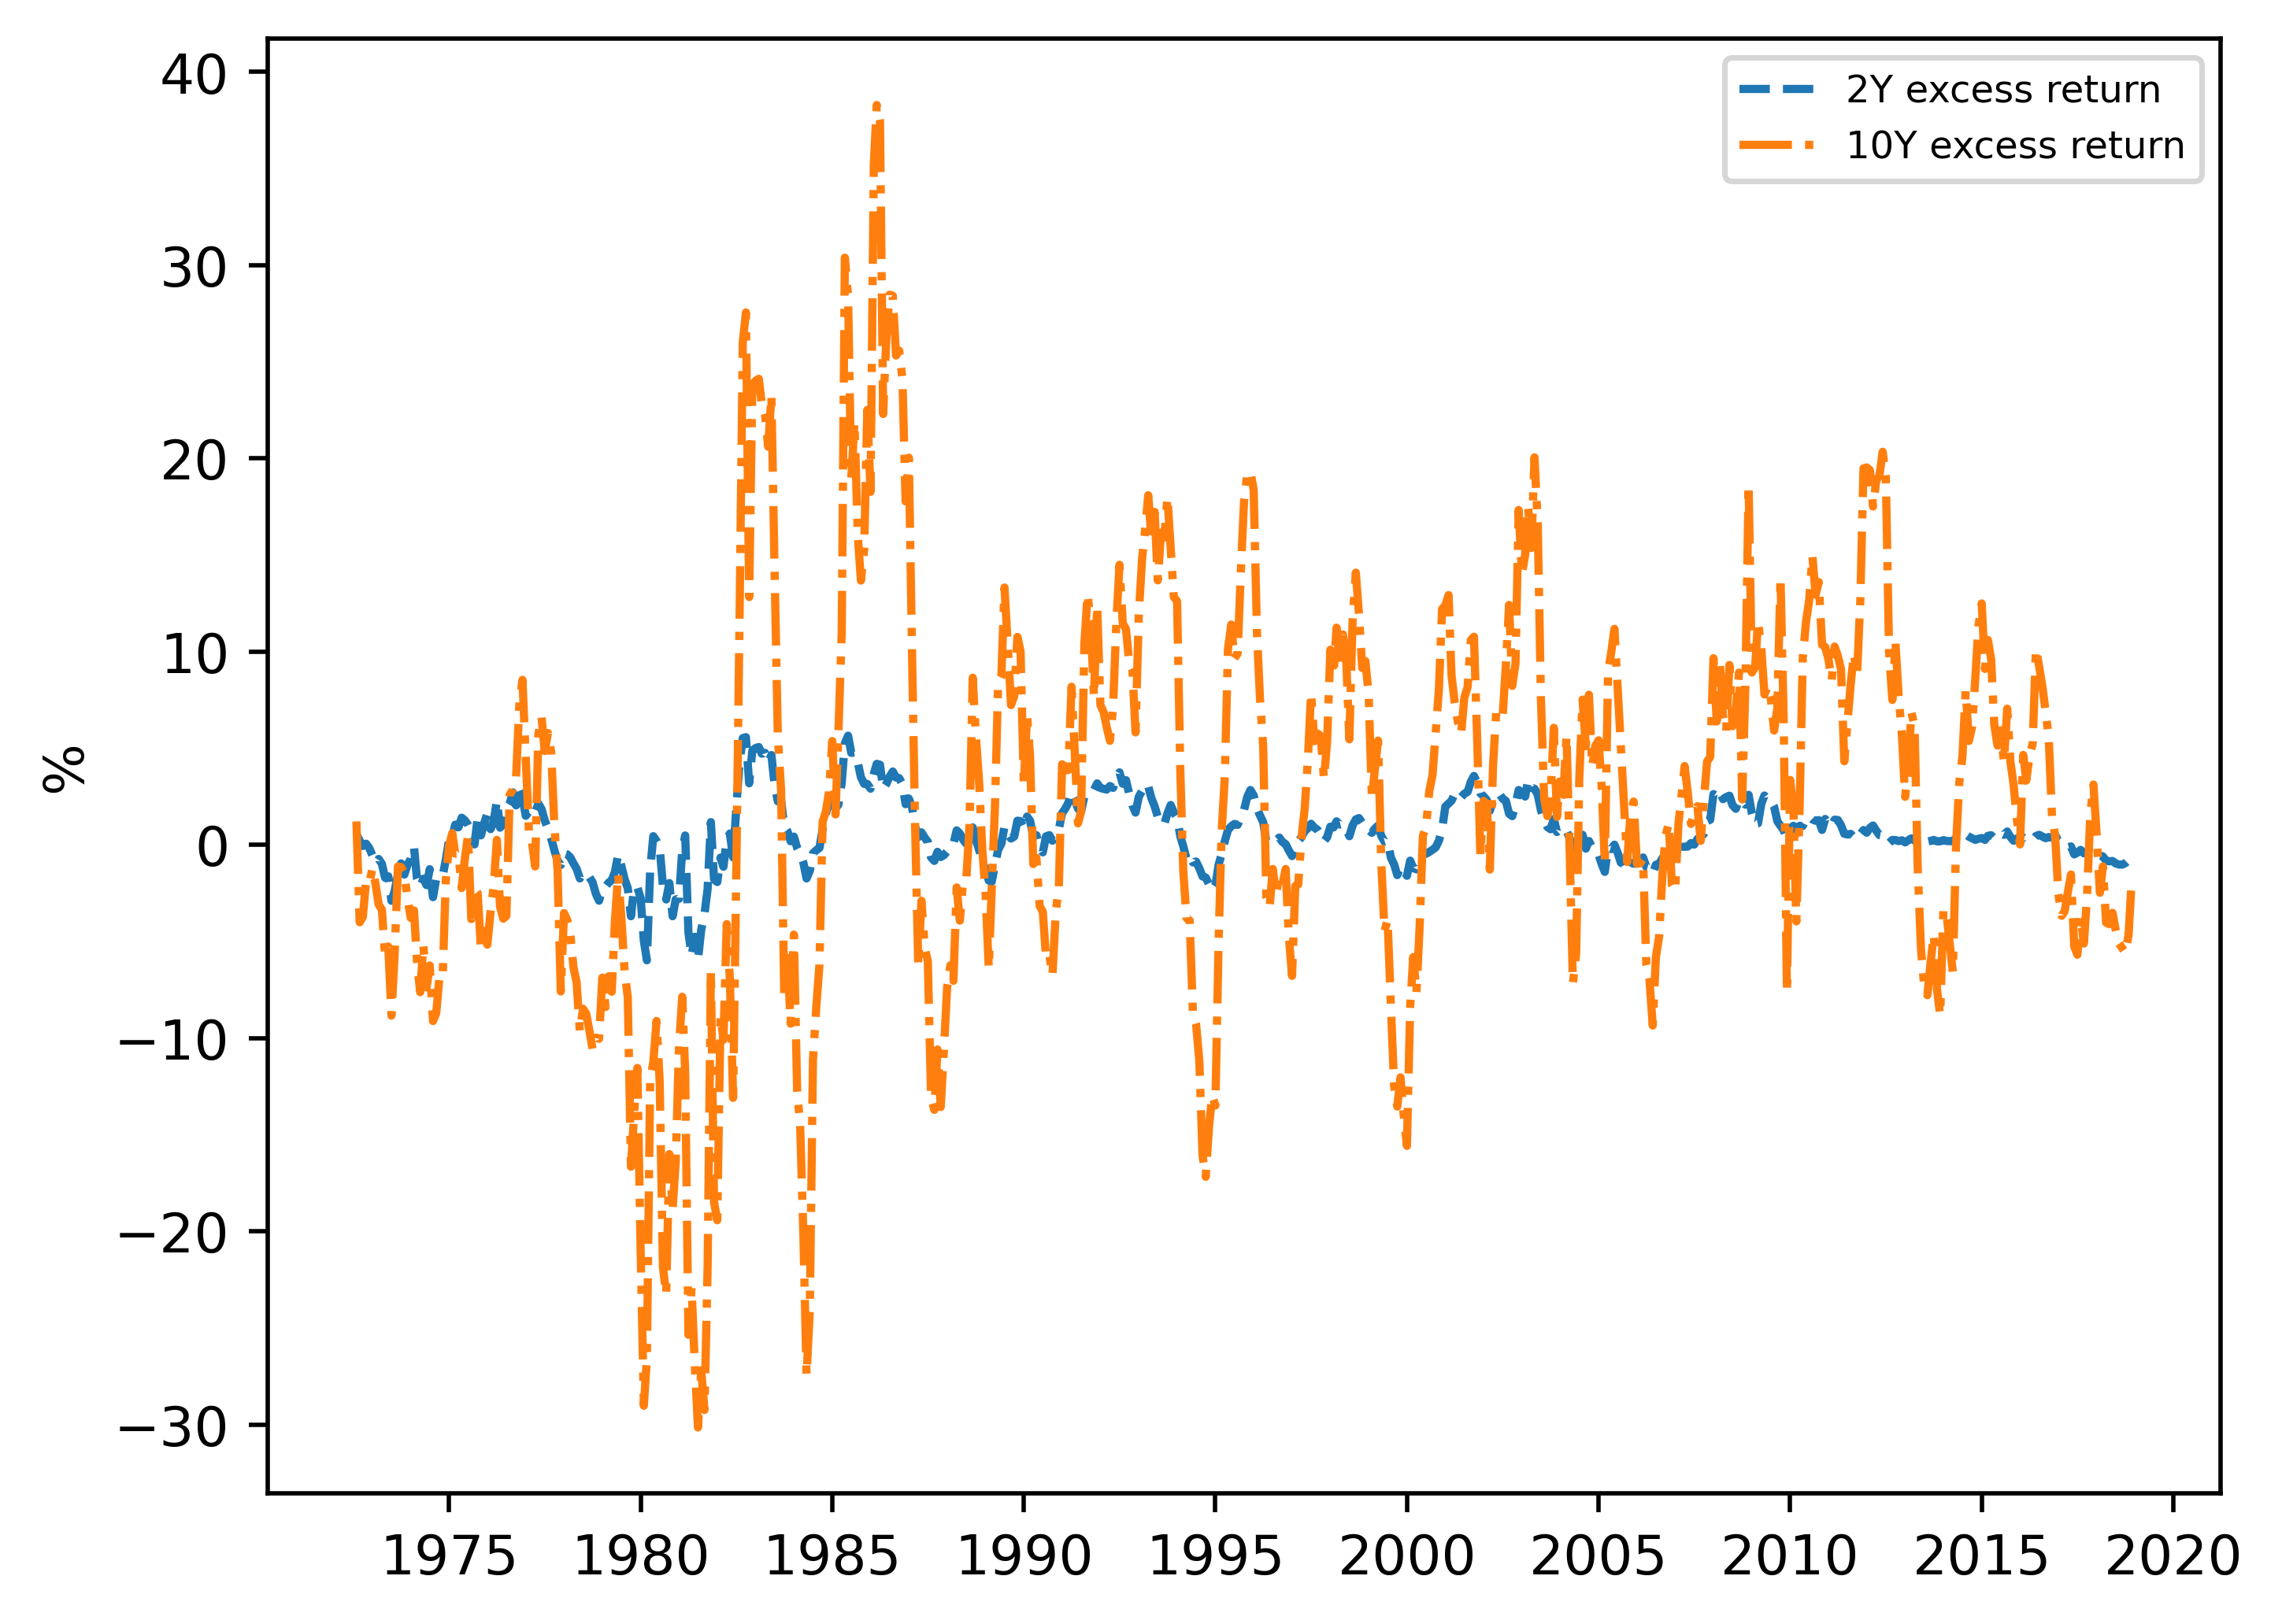

In [4]:
tables.show_figure("baseline_main", "Figure_ excess returns")

### Figure 3: Loadings of the first three principal components of yields and of changes in yields

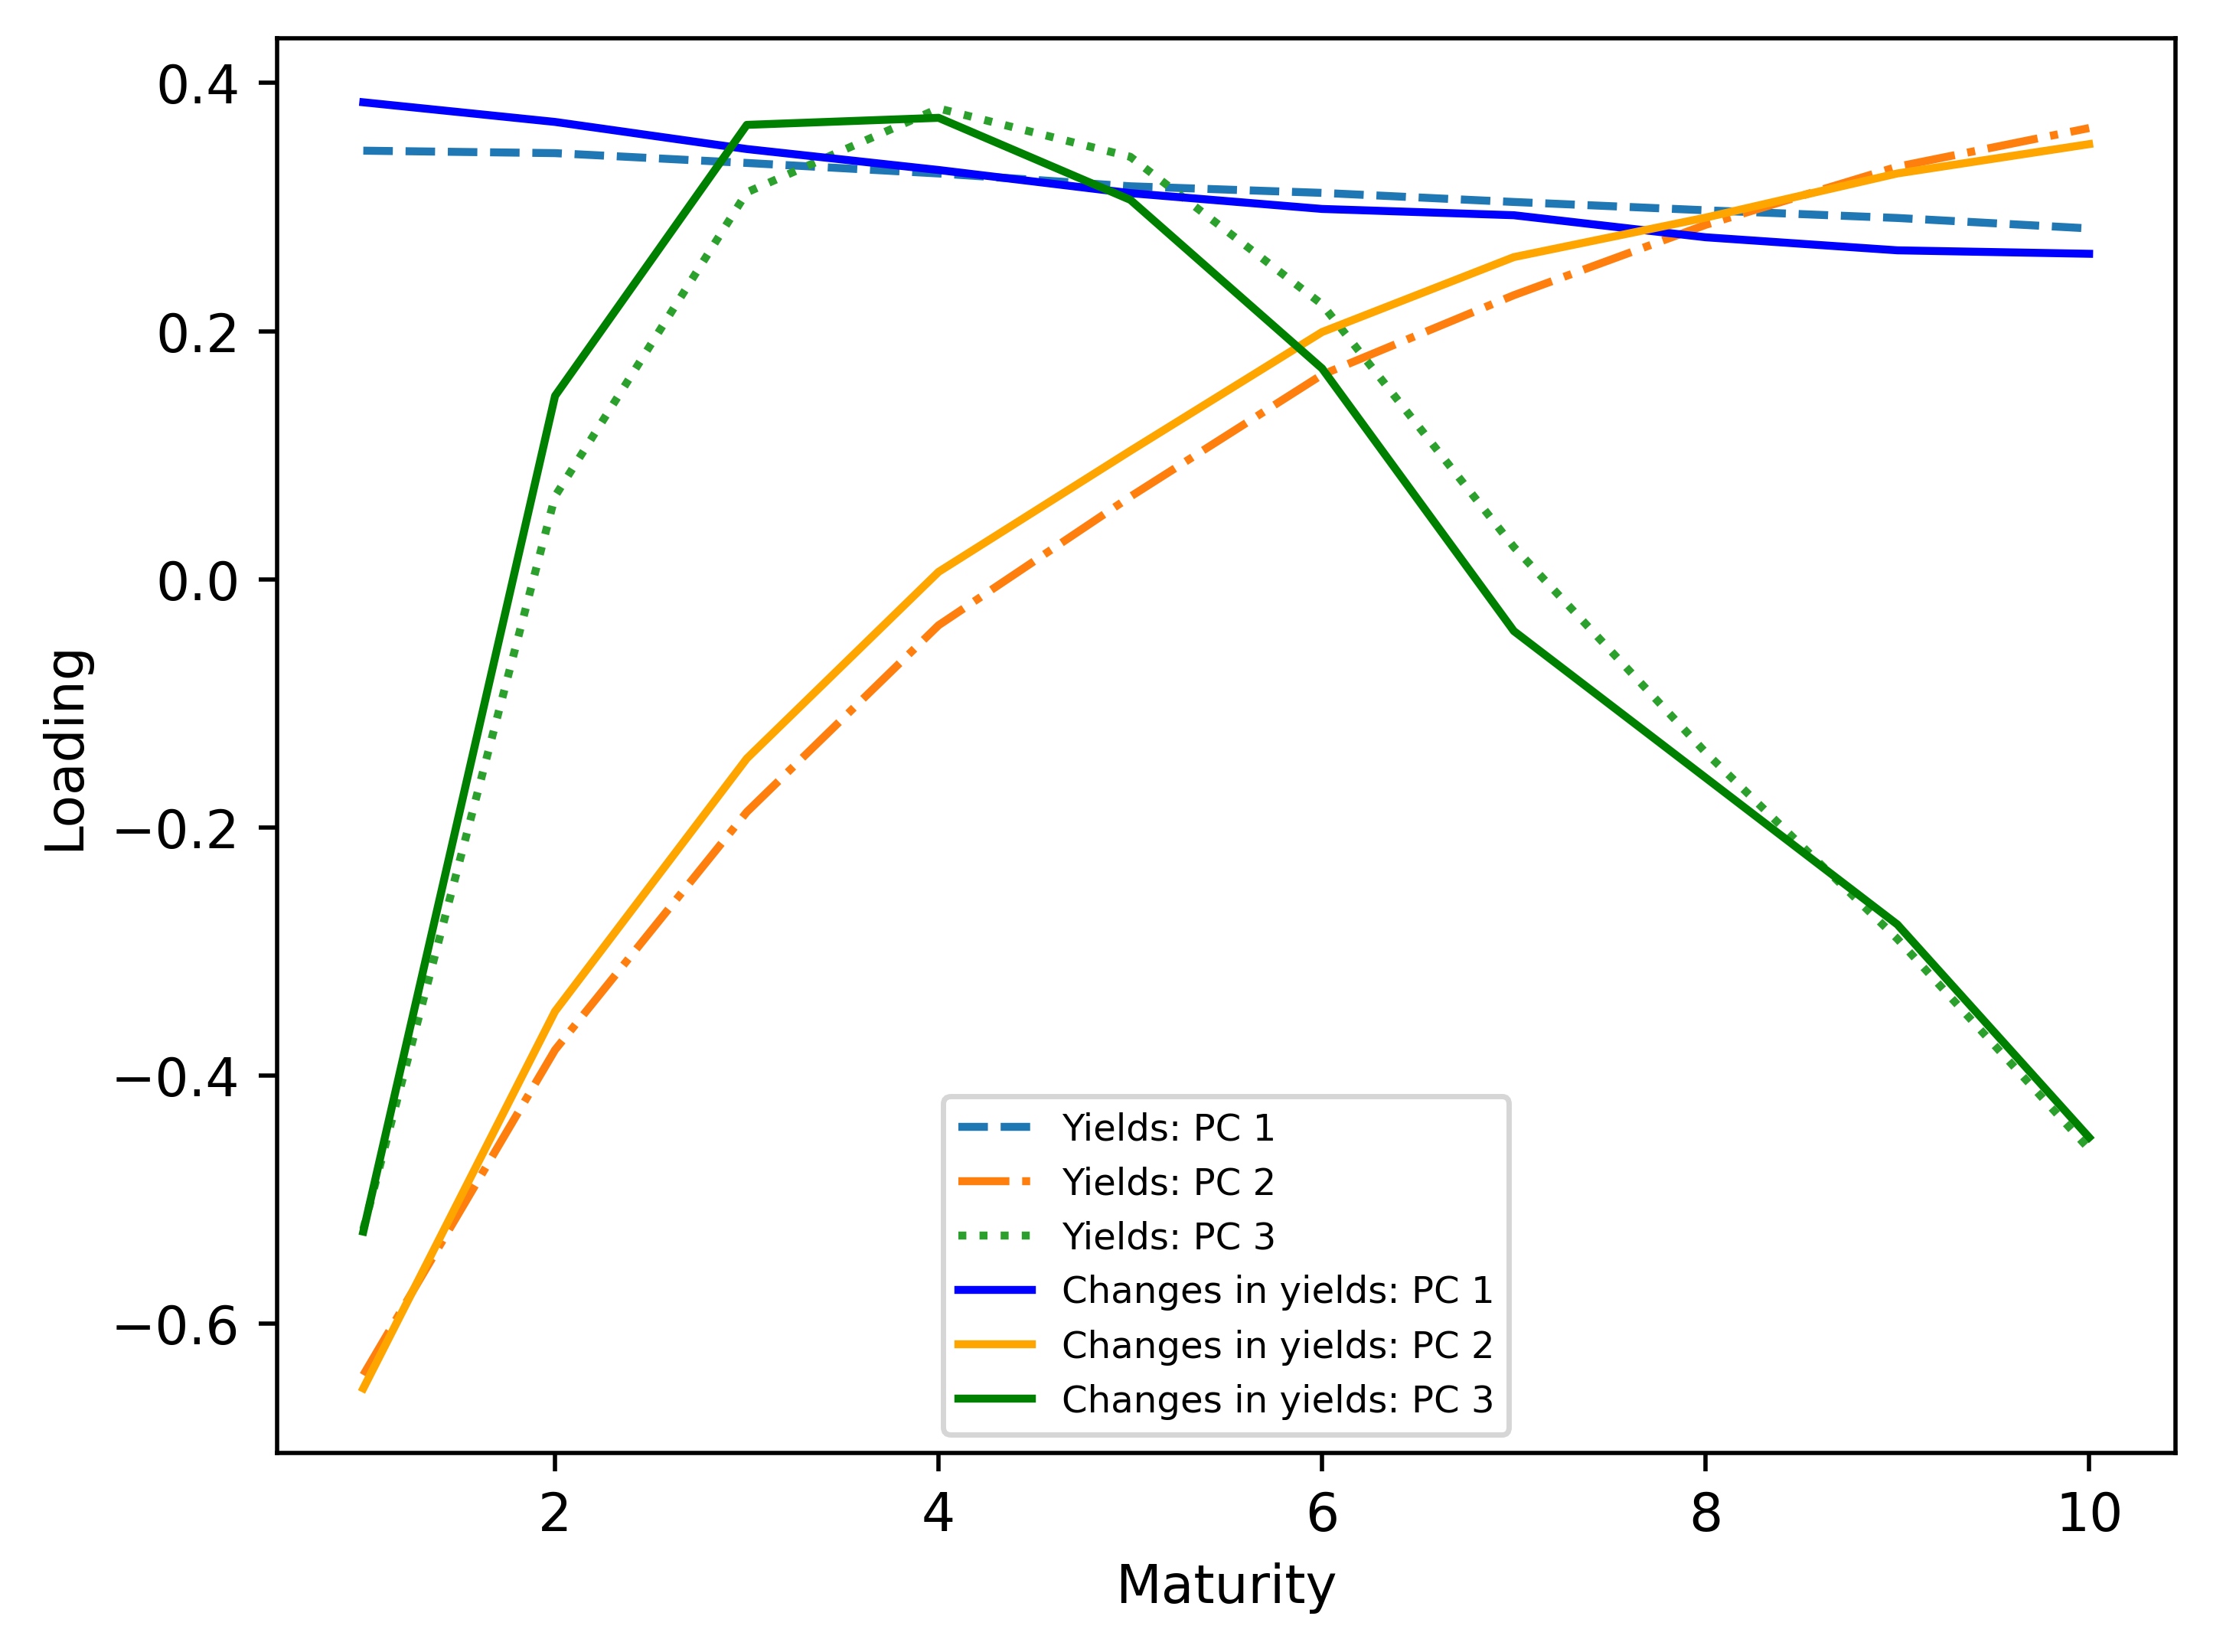

In [5]:
tables.show_figure("baseline_main", "Figure PC loadings yields")

### Figure 4: First three principal components of yields

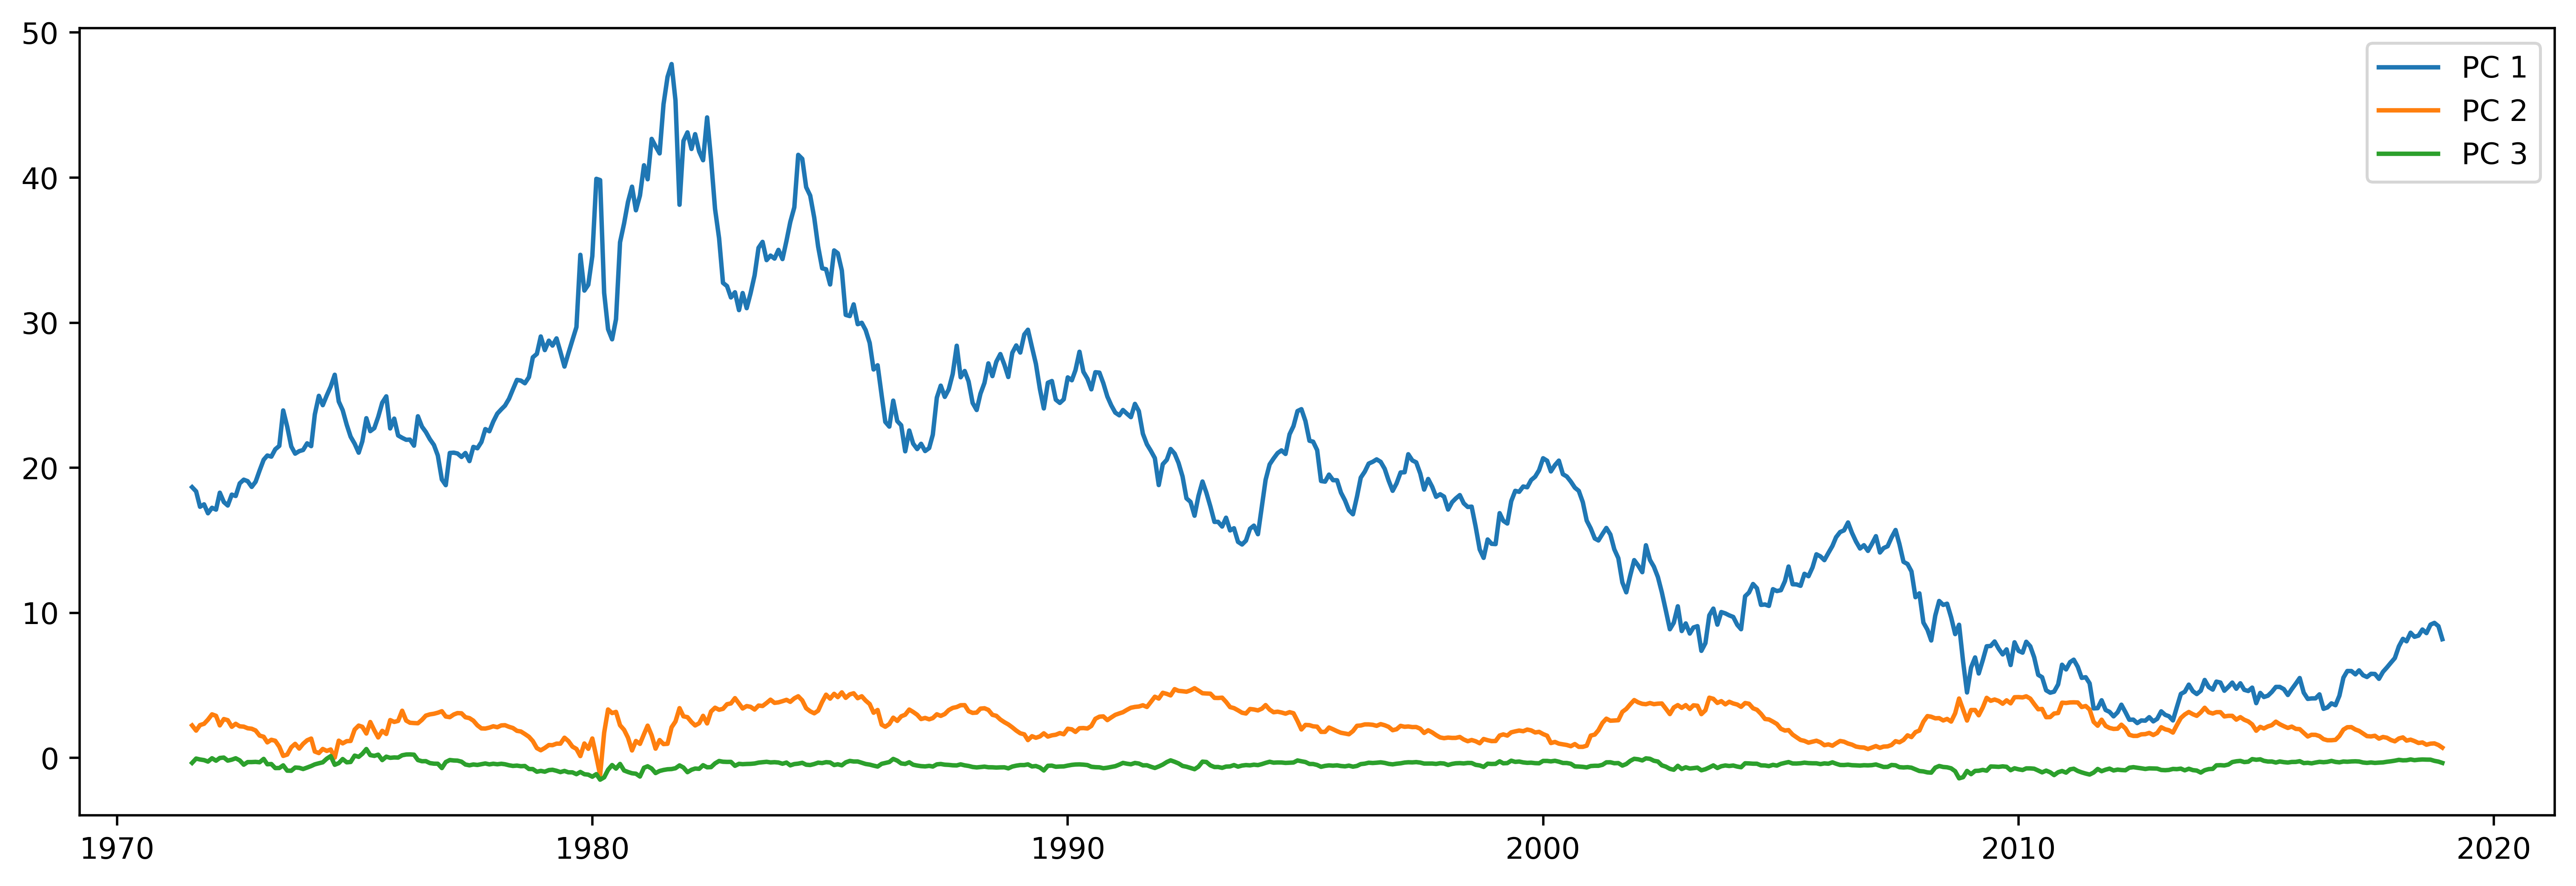

In [6]:
tables.show_figure("baseline_main", "Yields_ PCs figure")

### Figure 5: Principal components of changes in yields vs changes in principal components of yields

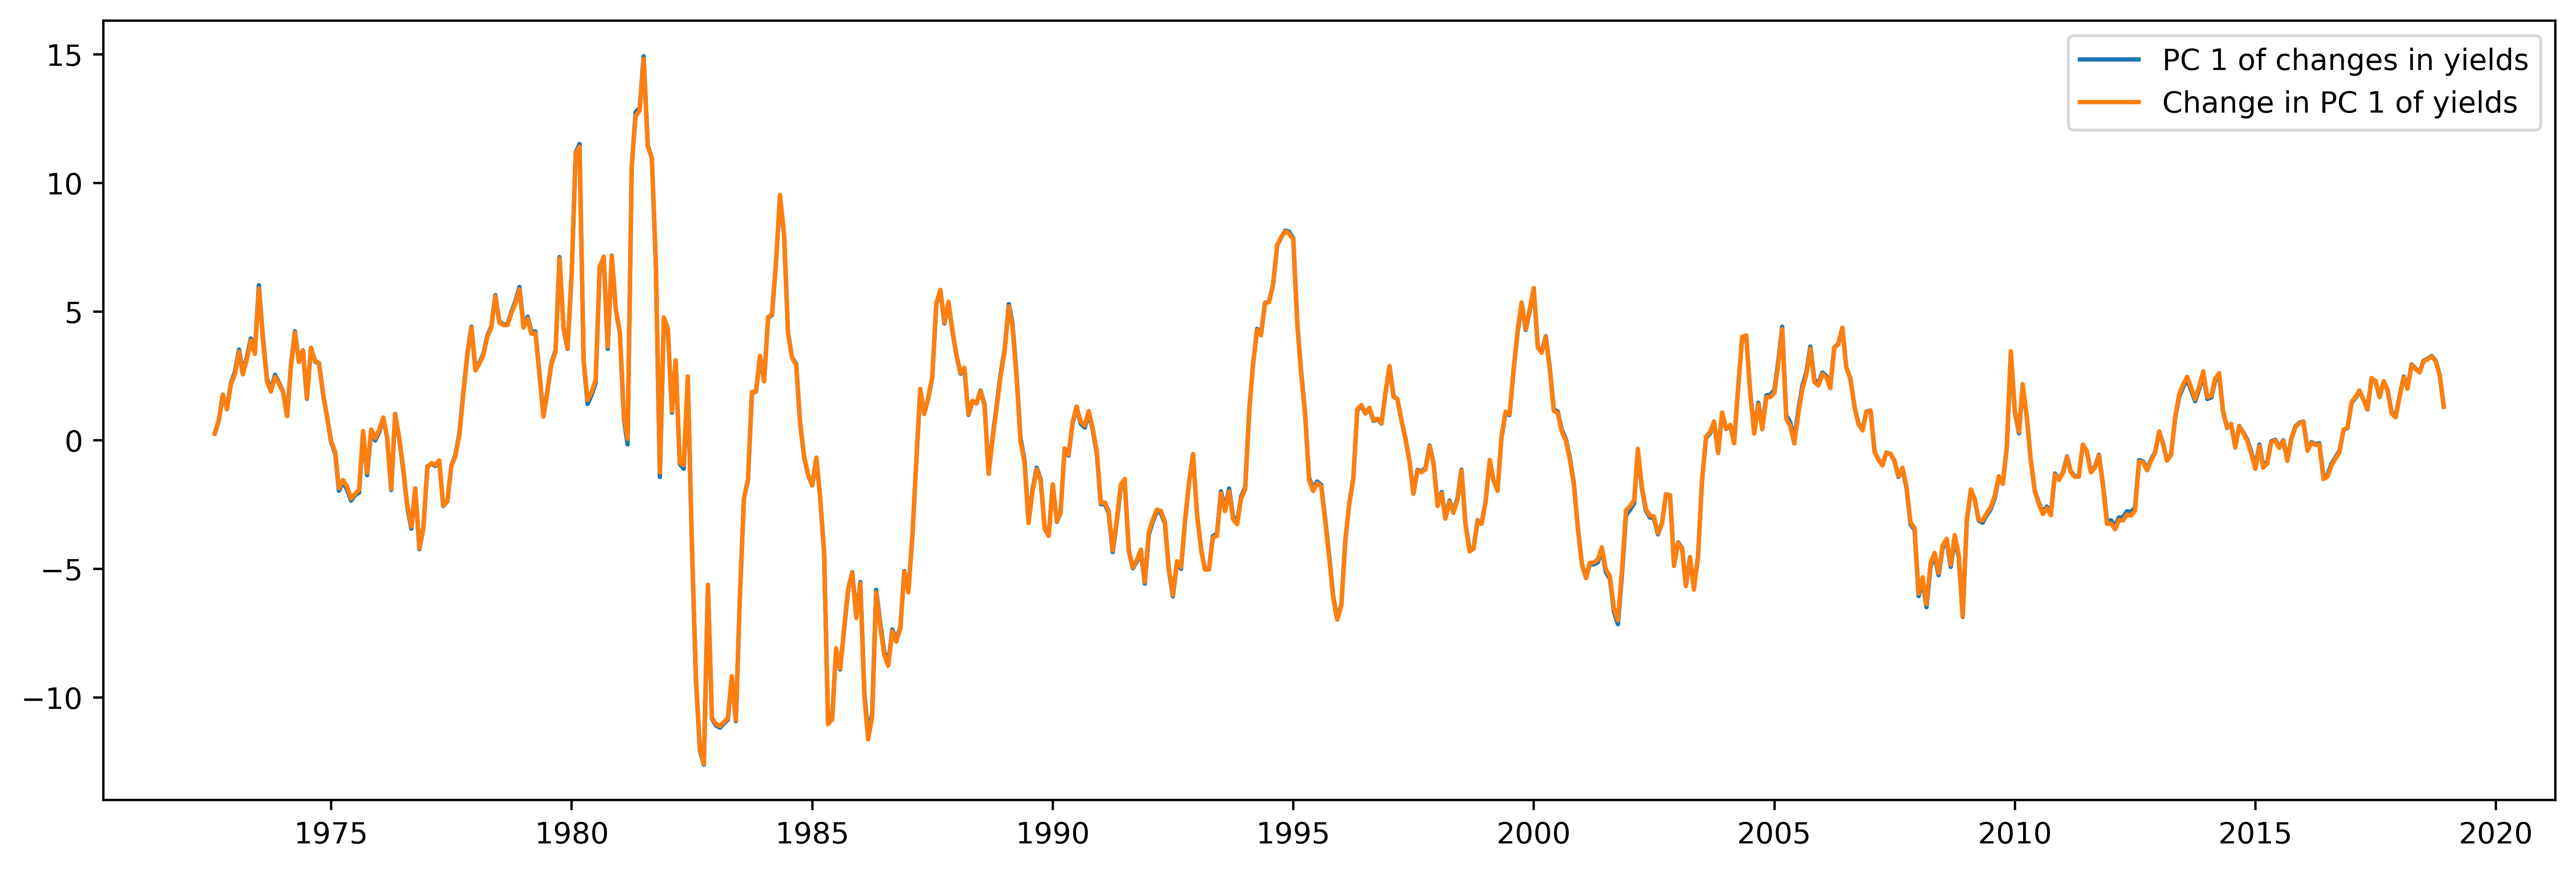

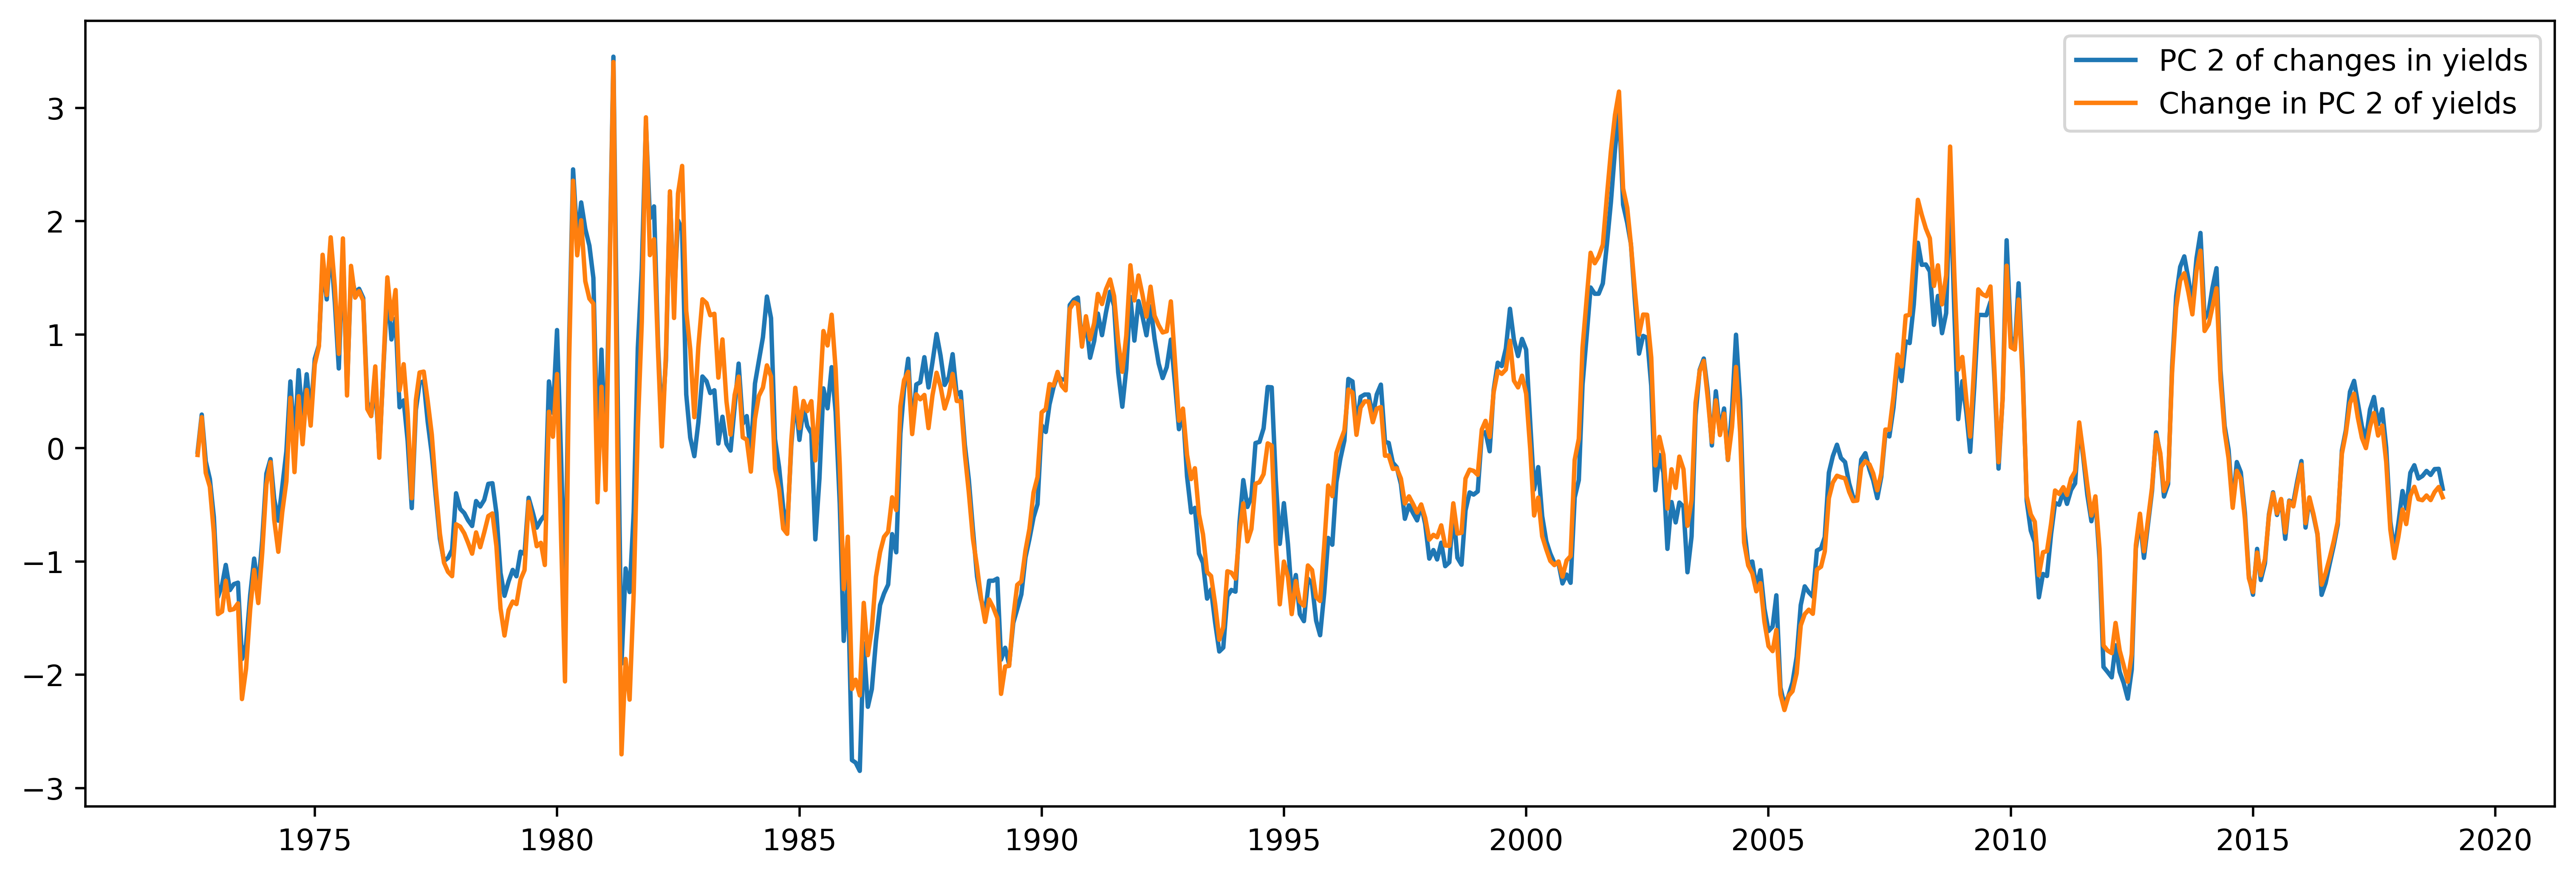

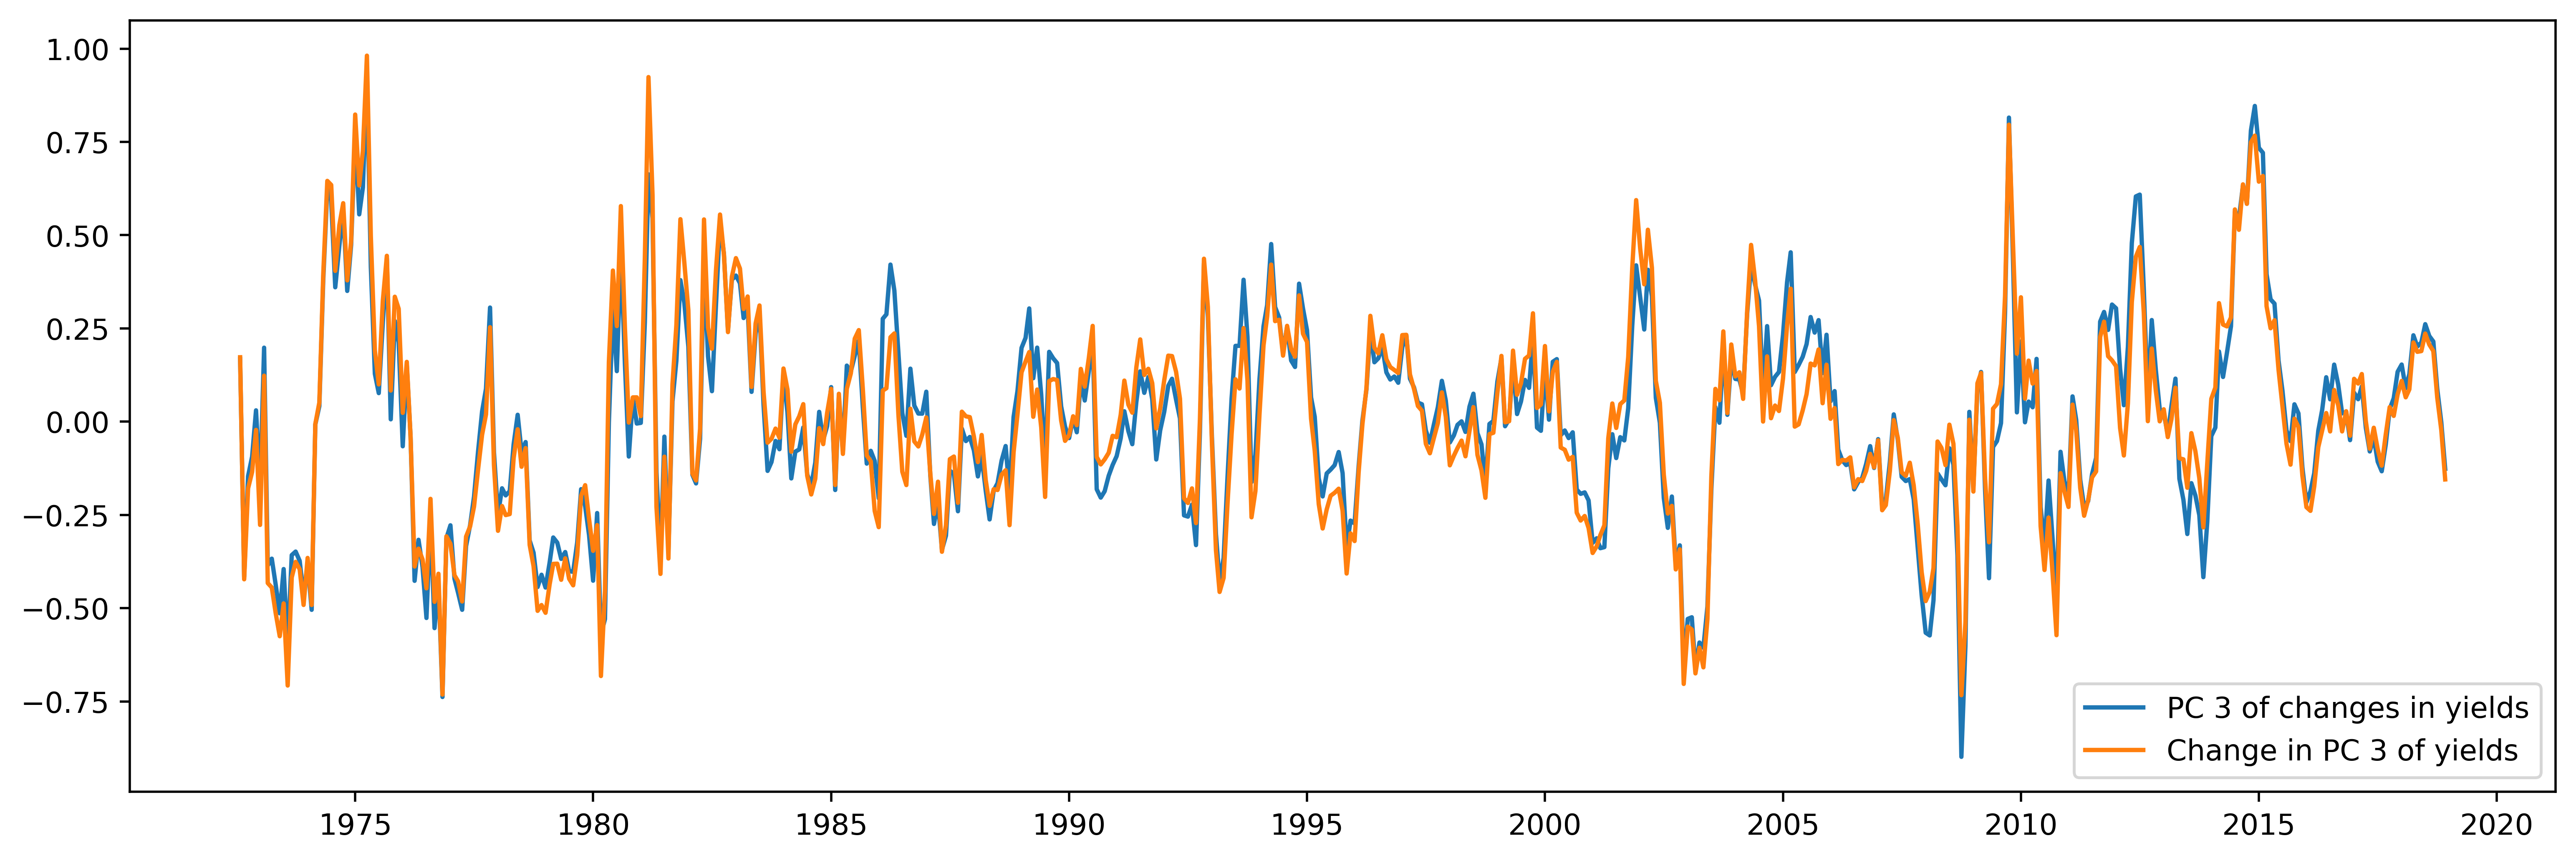

In [7]:
for k in (1, 2, 3):
    tables.show_figure("baseline_main", f"Figure_ pcs of changes vs changes in pcs {k}")

### Numbers quoted in the text (Sections 2.1 and 4.2)

In [8]:
tables.text_numbers()

,paper,reproduced,check
variance explained by first three PCs of yield changes (%),99.75,99.77,✓
correlation PC1 of changes vs change in PC1 (%),100.00,99.99,✓
correlation PC2 of changes vs change in PC2 (%),97.00,97.04,✓
correlation PC3 of changes vs change in PC3 (%),96.90,96.87,✓
"correlation Cieslak-Povala vs yield-change forecasts, min (%)",25.00,24.72,✓
"correlation Cieslak-Povala vs yield-change forecasts, max (%)",32.00,32.00,✓


## Section 2.2 — Predicting excess bond returns

### Table 1: Full-sample bond risk premia regressions

Coefficients with Newey-West *t*-statistics in parentheses.

In [9]:
tables.full_sample("Table 1")

const            PC1             PC2  \
row      source                                                      
Y, n=2   paper          0.55 (2.80)    0.03 (1.41)     0.46 (2.86)   
         reproduced  0.55*** (2.80)    0.03 (1.41)  0.46*** (2.86)   
Y, n=3   paper          0.96 (2.72)    0.04 (0.86)     0.94 (3.13)   
         reproduced  0.96*** (2.72)    0.04 (0.86)  0.94*** (3.13)   
Y, n=4   paper          1.35 (2.80)    0.03 (0.59)     1.49 (3.54)   
         reproduced  1.35*** (2.80)    0.03 (0.59)  1.49*** (3.54)   
Y, n=5   paper          1.54 (2.64)    0.02 (0.27)     1.95 (3.79)   
         reproduced  1.54*** (2.64)    0.02 (0.27)  1.95*** (3.79)   
Y, n=7   paper          1.95 (2.48)    0.02 (0.19)     2.98 (4.12)   
         reproduced   1.95** (2.48)    0.02 (0.19)  2.98*** (4.12)   
Y, n=10  paper          2.26 (2.13)  -0.02 (-0.16)     4.34 (4.37)   
         reproduced   2.26** (2.13)  -0.02 (-0.16)  4.34*** (4.37)   
ΔY, n=2  paper          0.59 (3.03)  -0.07 (-1.29)     0.52 (2.76)   
         reproduced  0.59*** (3.03)  -0.07 (-1.29)  0.52*** (2.76)   
ΔY, n=3  paper          1.02 (2.88)  -0.12 (-1.18)     0.99 (2.92)   
         reproduced  1.02*** (2.88)  -0.12 (-1.18)  0.99*** (2.92)   
ΔY, n=4  paper          1.43 (2.87)  -0.15 (-1.05)     1.38 (2.93)   
         reproduced  1.43*** (2.87)  -0.15 (-1.05)  1.38*** (2.93)   
ΔY, n=5  paper          1.63 (2.63)  -0.16 (-0.88)     1.67 (2.89)   
         reproduced  1.63*** (2.63)  -0.16 (-0.88)  1.67*** (2.89)   
ΔY, n=7  paper          2.09 (2.39)  -0.16 (-0.62)     2.31 (3.01)   
         reproduced   2.09** (2.39)  -0.16 (-0.62)  2.31*** (3.01)   
ΔY, n=10 paper          2.47 (2.01)  -0.15 (-0.42)     2.93 (2.86)   
         reproduced   2.47** (2.01)  -0.15 (-0.42)  2.93*** (2.86)   

                              PC3     R2 check  
row      source                                 
Y, n=2   paper        0.96 (1.68)  0.136        
         reproduced  0.96* (1.68)  0.136     ✓  
Y, n=3   paper        1.76 (1.72)  0.139        
         reproduced  1.76* (1.72)  0.139     ✓  
Y, n=4   paper         2.5 (1.75)  0.162        
         reproduced  2.50* (1.75)  0.162     ✓  
Y, n=5   paper        2.98 (1.67)  0.171        
         reproduced  2.98* (1.67)  0.171     ✓  
Y, n=7   paper        2.86 (1.19)  0.190        
         reproduced   2.86 (1.19)  0.190     ✓  
Y, n=10  paper        2.25 (0.67)  0.202        
         reproduced   2.25 (0.67)  0.202     ✓  
ΔY, n=2  paper        0.72 (1.81)  0.131        
         reproduced  0.72* (1.81)  0.131     ✓  
ΔY, n=3  paper        1.35 (1.76)  0.138        
         reproduced  1.35* (1.76)  0.138     ✓  
ΔY, n=4  paper        1.95 (1.75)  0.134        
         reproduced  1.95* (1.75)  0.134     ✓  
ΔY, n=5  paper        2.25 (1.58)  0.124        
         reproduced   2.25 (1.58)  0.124     ✓  
ΔY, n=7  paper        2.52 (1.22)  0.112        
         reproduced   2.52 (1.22)  0.112     ✓  
ΔY, n=10 paper        2.17 (0.71)  0.089        
         reproduced   2.17 (0.71)  0.089     ✓

### Table 2: Out-of-sample $R^2$ — linear models (Clark-West *p*-values in parentheses)

In [10]:
tables.oos_r2("Table 2")

n=2               n=3  \
row                   source                                           
Y                     paper                 -0.857            -0.656   
                      reproduced            -0.857            -0.656   
Y (without PC1)       paper                 -0.206            -0.158   
                      reproduced            -0.206            -0.158   
ΔY                    paper                  0.177             0.202   
                      reproduced  0.177*** (0.003)  0.202*** (0.002)   
Y and ΔY              paper                 -0.949            -0.752   
                      reproduced            -0.949            -0.752   
F                     paper                 -0.319            -0.233   
                      reproduced            -0.319            -0.233   
ΔF                    paper                  0.199             0.197   
                      reproduced  0.199*** (0.002)  0.197*** (0.002)   
Cochrane and Piazzesi paper                 -0.411            -0.407   
                      reproduced            -0.411            -0.407   
Diebold and Li        paper                 -0.236            -0.192   
                      reproduced            -0.236            -0.192   

                                               n=4               n=5  \
row                   source                                           
Y                     paper                 -0.547            -0.422   
                      reproduced            -0.547            -0.422   
Y (without PC1)       paper                 -0.112            -0.086   
                      reproduced            -0.112            -0.086   
ΔY                    paper                  0.204             0.188   
                      reproduced  0.204*** (0.002)  0.188*** (0.002)   
Y and ΔY              paper                 -0.676            -0.563   
                      reproduced            -0.676            -0.563   
F                     paper                 -0.167            -0.085   
                      reproduced            -0.167            -0.085   
ΔF                    paper                  0.180             0.157   
                      reproduced  0.180*** (0.003)  0.157*** (0.003)   
Cochrane and Piazzesi paper                 -0.413            -0.398   
                      reproduced            -0.413            -0.398   
Diebold and Li        paper                 -0.165            -0.147   
                      reproduced            -0.165            -0.147   

                                               n=7              n=10 check  
row                   source                                                
Y                     paper                 -0.319            -0.148        
                      reproduced            -0.319            -0.148     ✓  
Y (without PC1)       paper                 -0.003             0.063        
                      reproduced            -0.003   0.063** (0.017)     ✓  
ΔY                    paper                  0.173             0.145        
                      reproduced  0.173*** (0.002)  0.145*** (0.003)     ✓  
Y and ΔY              paper                 -0.449            -0.272        
                      reproduced            -0.449            -0.272     ✓  
F                     paper                 -0.056             0.034        
                      reproduced            -0.056   0.034** (0.014)     ✓  
ΔF                    paper                  0.139             0.125        
                      reproduced  0.139*** (0.003)  0.125*** (0.003)     ✓  
Cochrane and Piazzesi paper                 -0.434            -0.449        
                      reproduced            -0.434            -0.449     ✓  
Diebold and Li        paper                 -0.141            -0.059        
                      reproduced            -0.141            -0.059     ✓

## Section 2.3 — Economic value

### Table 3: Mean-variance investor — linear models (*p*-values in parentheses)

In [11]:
tables.economic_value("Table 3")

n=2            n=3  \
row                                 source                                     
CER (%): Benchmark (EH)             paper                4.14           4.35   
                                    reproduced           4.14           4.35   
CER (%): Y                          paper                3.03           2.98   
                                    reproduced           3.03           2.98   
CER (%): ΔY                         paper                4.12           4.69   
                                    reproduced           4.12   4.69 (0.246)   
CER (%): F                          paper                3.42           3.74   
                                    reproduced           3.42           3.74   
CER (%): ΔF                         paper                4.18           4.74   
                                    reproduced   4.18 (0.823)   4.74 (0.250)   
CER (%): Cochrane and Piazzesi      paper                3.32           3.33   
                                    reproduced           3.32           3.33   
CER (%): Diebold and Li             paper                3.25           3.34   
                                    reproduced           3.25           3.34   
Sharpe ratio: Benchmark (EH)        paper               0.577          0.549   
                                    reproduced          0.577          0.549   
Sharpe ratio: Y                     paper              -0.018          0.018   
                                    reproduced         -0.018          0.018   
Sharpe ratio: ΔY                    paper               0.573          0.567   
                                    reproduced          0.573  0.567 (0.901)   
Sharpe ratio: F                     paper               0.211          0.261   
                                    reproduced          0.211          0.262   
Sharpe ratio: ΔF                    paper               0.600          0.568   
                                    reproduced  0.600 (0.844)  0.568 (0.905)   
Sharpe ratio: Cochrane and Piazzesi paper               0.155          0.141   
                                    reproduced          0.155          0.141   
Sharpe ratio: Diebold and Li        paper               0.139          0.136   
                                    reproduced          0.139          0.136   

                                                          n=4             n=5  \
row                                 source                                      
CER (%): Benchmark (EH)             paper                4.42            4.24   
                                    reproduced           4.42            4.24   
CER (%): Y                          paper                3.10            3.20   
                                    reproduced           3.10            3.20   
CER (%): ΔY                         paper                5.03            5.01   
                                    reproduced  5.03* (0.065)  5.01** (0.035)   
CER (%): F                          paper                4.11            4.32   
                                    reproduced           4.11    4.32 (0.892)   
CER (%): ΔF                         paper                5.02            4.99   
                                    reproduced   5.02 (0.139)   4.99* (0.095)   
CER (%): Cochrane and Piazzesi      paper                3.32            3.14   
                                    reproduced           3.32            3.14   
CER (%): Diebold and Li             paper                3.54            3.54   
                                    reproduced           3.54            3.54   
Sharpe ratio: Benchmark (EH)        paper               0.566           0.517   
                                    reproduced          0.566           0.517   
Sharpe ratio: Y                     paper               0.080           0.117   
                                    reproduced          0.080           0.117   
Sharpe ratio: ΔY                    p

## Section 3 — Machine learning

The neural networks use 20 networks per forecast date, of which the 10 with the lowest validation loss are averaged
(Appendix G). With the software versions of `environment.yml`, re-running `run_nn.py` reproduces the stored results
exactly on the same machine; on other hardware small numerical differences are possible.

### Table 4: Out-of-sample $R^2$ — neural networks

In [12]:
tables.oos_r2("Table 4")

n=2               n=3  \
row                       source                                         
NN: y                     paper               -0.103            -0.061   
                          reproduced          -0.103            -0.061   
NN: Δy                    paper                0.022             0.063   
                          reproduced  0.022* (0.070)   0.063** (0.017)   
NN: f                     paper               -0.033            -0.005   
                          reproduced          -0.033            -0.005   
NN: Δf                    paper                0.021             0.047   
                          reproduced  0.021* (0.061)   0.047** (0.028)   
NN: Y                     paper               -0.049            -0.013   
                          reproduced          -0.049            -0.013   
NN: ΔY                    paper                0.031             0.113   
                          reproduced  0.031* (0.053)  0.113*** (0.003)   
NN: Cochrane and Piazzesi paper               -0.101            -0.083   
                          reproduced          -0.101            -0.083   
NN: Diebold and Li        paper               -0.127            -0.088   
                          reproduced          -0.127            -0.088   

                                                   n=4               n=5  \
row                       source                                           
NN: y                     paper                 -0.038            -0.032   
                          reproduced            -0.038            -0.032   
NN: Δy                    paper                  0.070             0.070   
                          reproduced   0.070** (0.011)   0.070** (0.012)   
NN: f                     paper                  0.004             0.004   
                          reproduced     0.004 (0.200)     0.004 (0.210)   
NN: Δf                    paper                  0.051             0.054   
                          reproduced   0.051** (0.023)   0.054** (0.023)   
NN: Y                     paper                 -0.020            -0.003   
                          reproduced            -0.020            -0.003   
NN: ΔY                    paper                  0.115             0.121   
                          reproduced  0.115*** (0.002)  0.121*** (0.001)   
NN: Cochrane and Piazzesi paper                 -0.068            -0.061   
                          reproduced            -0.068            -0.061   
NN: Diebold and Li        paper                 -0.069            -0.056   
                          reproduced            -0.069            -0.056   

                                                   n=7              n=10 check  
row                       source                                                
NN: y                     paper                 -0.013            -0.004        
                          reproduced            -0.013            -0.004     ✓  
NN: Δy                    paper                  0.069             0.068        
                          reproduced   0.069** (0.012)   0.068** (0.014)     ✓  
NN: f                     paper                  0.004            -0.002        
                          reproduced     0.004 (0.200)            -0.002     ✓  
NN: Δf                    paper                  0.046             0.048        
                          reproduced   0.046** (0.027)   0.048** (0.029)     ✓  
NN: Y                     paper                 -0.010             0.005        
                          reproduced            -0.010    0.005* (0.096)     ✓  
NN: ΔY                    paper                  0.122             0.112        
                          reproduced  0.122*** (0.001)  0.112*** (0.000)     ✓  
NN: Cochrane and Piazzesi paper                 -0.052            -0.038        
                          reproduced            -0.052            -0.038     ✓  
NN: Diebold and Li        paper                 -0.

### Table 5: Mean-variance investor — neural networks

In [13]:
tables.economic_value("Table 5")

n=2            n=3  \
row                                     source                             
CER (%): NN: y                          paper        3.78           4.08   
                                        reproduced   3.78           4.08   
CER (%): NN: Δy                         paper        4.06           4.54   
                                        reproduced   4.06   4.54 (0.305)   
CER (%): NN: f                          paper        3.93           4.25   
                                        reproduced   3.93           4.25   
CER (%): NN: Δf                         paper        4.10           4.44   
                                        reproduced   4.10   4.44 (0.590)   
CER (%): NN: Y                          paper        3.85           4.20   
                                        reproduced   3.85           4.20   
CER (%): NN: ΔY                         paper        4.08           4.73   
                                        reproduced   4.08  4.73* (0.062)   
CER (%): NN: Cochrane and Piazzesi      paper        3.99           4.16   
                                        reproduced   3.99           4.16   
CER (%): NN: Diebold and Li             paper        3.74           3.96   
                                        reproduced   3.74           3.96   
Sharpe ratio: NN: y                     paper       0.437          0.465   
                                        reproduced  0.437          0.465   
Sharpe ratio: NN: Δy                    paper       0.547          0.543   
                                        reproduced  0.547          0.543   
Sharpe ratio: NN: f                     paper       0.473          0.533   
                                        reproduced  0.473          0.533   
Sharpe ratio: NN: Δf                    paper       0.550          0.521   
                                        reproduced  0.550          0.521   
Sharpe ratio: NN: Y                     paper       0.457          0.494   
                                        reproduced  0.457          0.494   
Sharpe ratio: NN: ΔY                    paper       0.561          0.595   
                                        reproduced  0.561  0.595 (0.627)   
Sharpe ratio: NN: Cochrane and Piazzesi paper       0.511          0.487   
                                        reproduced  0.511          0.487   
Sharpe ratio: NN: Diebold and Li        paper       0.419          0.405   
                                        reproduced  0.419          0.405   

                                                               n=4  \
row                                     source                       
CER (%): NN: y                          paper                 4.25   
                                        reproduced            4.25   
CER (%): NN: Δy                         paper                 4.76   
                                        reproduced    4.76 (0.113)   
CER (%): NN: f                          paper                 4.33   
                                        reproduced            4.33   
CER (%): NN: Δf                         paper                 4.66   
                                        reproduced    4.66 (0.227)   
CER (%): NN: Y                          paper                 4.25   
                                        reproduced            4.25   
CER (%): NN: ΔY                         paper                 4.96   
                                        reproduced  4.96** (0.019)   
CER (%): NN: Cochrane and Piazzesi      paper                 4.24   
                                        reproduced            4.24   
CER (%): NN: Diebold and Li             paper                 4.10   
                                        reproduced            4.10   
Sharpe ratio: NN: y                     paper                0.515   
                                        reproduced           0.515   
Sharpe ratio: NN: Δy                    paper                0.554   

## Section 4 — Machine learning and added value of macro data

### Table 6: Out-of-sample $R^2$ — with macro data

In [14]:
tables.oos_r2("Table 6")

n=2               n=3  \
row                    source                                           
Y and Z                paper                 -0.593            -0.444   
                       reproduced            -0.593            -0.444   
F and Z                paper                 -0.185            -0.108   
                       reproduced            -0.185            -0.108   
ΔY and Z               paper                  0.057             0.093   
                       reproduced  0.057*** (0.007)  0.093*** (0.005)   
ΔF and Z               paper                  0.108             0.128   
                       reproduced  0.108*** (0.003)  0.128*** (0.002)   
Cieslak and Povala     paper                 -0.513            -0.277   
                       reproduced            -0.513            -0.277   
NN: y and Z            paper                 -0.015             0.057   
                       reproduced            -0.015  0.057*** (0.001)   
NN: f and Z            paper                 -0.082             0.007   
                       reproduced            -0.082  0.007*** (0.003)   
NN: Δy and Z           paper                 -0.439            -0.159   
                       reproduced            -0.439            -0.159   
NN: Δf and Z           paper                 -0.446            -0.175   
                       reproduced            -0.446            -0.175   
NN: Cieslak and Povala paper                  0.027             0.076   
                       reproduced    0.027* (0.072)   0.076** (0.026)   

                                                n=4               n=5  \
row                    source                                           
Y and Z                paper                 -0.394            -0.297   
                       reproduced            -0.394            -0.297   
F and Z                paper                 -0.090            -0.019   
                       reproduced            -0.090            -0.019   
ΔY and Z               paper                  0.140             0.184   
                       reproduced  0.140*** (0.001)  0.184*** (0.000)   
ΔF and Z               paper                  0.160             0.171   
                       reproduced  0.160*** (0.001)  0.171*** (0.001)   
Cieslak and Povala     paper                 -0.151            -0.039   
                       reproduced            -0.151            -0.039   
NN: y and Z            paper                  0.069             0.106   
                       reproduced  0.069*** (0.001)  0.106*** (0.001)   
NN: f and Z            paper                  0.040             0.087   
                       reproduced  0.040*** (0.002)  0.087*** (0.001)   
NN: Δy and Z           paper                 -0.096            -0.017   
                       reproduced            -0.096            -0.017   
NN: Δf and Z           paper                 -0.109            -0.024   
                       reproduced            -0.109            -0.024   
NN: Cieslak and Povala paper                  0.112             0.136   
                       reproduced   0.112** (0.011)  0.136*** (0.004)   

                                                n=7              n=10 check  
row                    source                                                
Y and Z                paper                 -0.226            -0.079        
                       reproduced            -0.226            -0.079     ✓  
F and Z                paper                 -0.061            -0.003        
                       reproduced            -0.061            -0.003     ✓  
ΔY and Z               paper                  0.166             0.230        
                       reproduced  0.166*** (0.000)  0.230*** (0.000)     ✓  
ΔF and Z               paper                  0.171             0.237        
                       reproduced  0.171*** (0.000)  0.237*** (0.000)     ✓  
Cieslak and Povala     paper                  0.122   

### Table 7: Mean-variance investor — including macro data

In [15]:
tables.economic_value("Table 7")

n=2  \
row                                  source                      
CER (%): Y and Z                     paper                3.29   
                                     reproduced           3.29   
CER (%): F and Z                     paper                3.66   
                                     reproduced           3.66   
CER (%): ΔY and Z                    paper                4.11   
                                     reproduced           4.11   
CER (%): ΔF and Z                    paper                4.19   
                                     reproduced   4.19 (0.761)   
CER (%): Cieslak and Povala          paper                3.59   
                                     reproduced           3.59   
CER (%): NN: y and Z                 paper                4.16   
                                     reproduced   4.16 (0.854)   
CER (%): NN: f and Z                 paper                4.16   
                                     reproduced   4.16 (0.850)   
CER (%): NN: Δy and Z                paper                4.26   
                                     reproduced   4.26 (0.150)   
CER (%): NN: Δf and Z                paper                4.21   
                                     reproduced   4.21 (0.333)   
CER (%): NN: Cieslak and Povala      paper                4.08   
                                     reproduced           4.08   
Sharpe ratio: Y and Z                paper               0.143   
                                     reproduced          0.143   
Sharpe ratio: F and Z                paper               0.336   
                                     reproduced          0.336   
Sharpe ratio: ΔY and Z               paper               0.565   
                                     reproduced          0.565   
Sharpe ratio: ΔF and Z               paper               0.595   
                                     reproduced  0.595 (0.851)   
Sharpe ratio: Cieslak and Povala     paper               0.348   
                                     reproduced          0.348   
Sharpe ratio: NN: y and Z            paper               0.587   
                                     reproduced  0.587 (0.902)   
Sharpe ratio: NN: f and Z            paper               0.584   
                                     reproduced  0.584 (0.884)   
Sharpe ratio: NN: Δy and Z           paper               0.623   
                                     reproduced  0.623 (0.318)   
Sharpe ratio: NN: Δf and Z           paper               0.598   
                                     reproduced  0.598 (0.591)   
Sharpe ratio: NN: Cieslak and Povala paper               0.565   
                                     reproduced          0.565   

                                                            n=3  \
row                                  source                       
CER (%): Y and Z                     paper                 3.37   
                                     reproduced            3.37   
CER (%): F and Z                     paper                 4.03   
                                     reproduced            4.03   
CER (%): ΔY and Z                    paper                 4.70   
                                     reproduced    4.70 (0.212)   
CER (%): ΔF and Z                    paper                 4.77   
                                     reproduced    4.77 (0.143)   
CER (%): Cieslak and Povala          paper                 4.05   
                                     reproduced            4.05   
CER (%): NN: y and Z                 paper                 4.80   
                                     reproduced   4.80* (0.078)   
CER (%): NN: f and Z                 paper                 4.75   
                                     reproduced   4.75* (0.067)   
CER (%): NN: Δy and Z                paper                 4.93   
                                     reproduced  4.93** (0.013)   
CER (%): NN: Δf and Z                paper                 4.86   
             

### Footnote 14: macro data excluding the interest-rate series

Out-of-sample $R^2$ with yield factors only, with all macro factors ($Z$), and with macro factors estimated
without the 17 interest-rate and spread series of FRED-MD (columns 78–94 of `data/data_mccracken.csv`).

In [16]:
tables.ex_yields()

,n=2,n=3,n=4,n=5,n=7,n=10
factors,,,,,,
ΔY,0.177,0.202,0.204,0.188,0.173,0.145
ΔY and Z,0.057,0.093,0.140,0.184,0.166,0.230
ΔY and Z (ex yields),0.161,0.192,0.181,0.153,0.144,0.149
ΔF,0.199,0.197,0.180,0.157,0.139,0.125
ΔF and Z,0.108,0.128,0.160,0.171,0.171,0.237
ΔF and Z (ex yields),0.197,0.207,0.185,0.150,0.139,0.144
Y,-0.857,-0.656,-0.547,-0.422,-0.319,-0.148
Y and Z,-0.593,-0.444,-0.394,-0.297,-0.226,-0.079
Y and Z (ex yields),-0.743,-0.600,-0.534,-0.410,-0.315,-0.138


## Online Appendix

### Table A.1: Regressions in the spirit of Hanson, Lucca and Wright (2021), ten-year excess returns

Coefficients with Newey-West *t*-statistics in parentheses; settings (1)–(5) are the columns of the paper.

In [17]:
tables.hanson()

(1)  \
row                                source                         
pre-2000, 6 months: const          paper                  -8.75   
                                   reproduced   -8.75** (-2.12)   
pre-2000, 6 months: level          paper                   0.91   
                                   reproduced      0.91* (1.73)   
pre-2000, 6 months: slope          paper                   3.03   
                                   reproduced    3.03*** (3.15)   
pre-2000, 6 months: level_change   paper                          
                                   reproduced                     
pre-2000, 6 months: slope_change   paper                          
                                   reproduced                     
pre-2000, 6 months: adj-R2         paper                   0.10   
                                   reproduced              0.10   
pre-2000, 12 months: const         paper                 -17.82   
                                   reproduced  -17.82** (-2.55)   
pre-2000, 12 months: level         paper                   1.83   
                                   reproduced     1.83** (2.05)   
pre-2000, 12 months: slope         paper                   6.21   
                                   reproduced    6.21*** (3.82)   
pre-2000, 12 months: level_change  paper                          
                                   reproduced                     
pre-2000, 12 months: slope_change  paper                          
                                   reproduced                     
pre-2000, 12 months: adj-R2        paper                   0.23   
                                   reproduced              0.23   
post-2000, 6 months: const         paper                  -6.83   
                                   reproduced  -6.83*** (-3.46)   
post-2000, 6 months: level         paper                   1.60   
                                   reproduced    1.60*** (3.58)   
post-2000, 6 months: slope         paper                   3.51   
                                   reproduced    3.51*** (4.82)   
post-2000, 6 months: level_change  paper                          
                                   reproduced                     
post-2000, 6 months: slope_change  paper                          
                                   reproduced                     
post-2000, 6 months: adj-R2        paper                   0.24   
                                   reproduced              0.24   
post-2000, 12 months: const        paper                  -9.69   
                                   reproduced  -9.69*** (-3.99)   
post-2000, 12 months: level        paper                   2.21   
                                   reproduced    2.21*** (3.51)   
post-2000, 12 months: slope        paper                   5.49   
                                   reproduced    5.49*** (5.79)   
post-2000, 12 months: level_change paper                          
                                   reproduced                     
post-2000, 12 months: slope_change paper                          
                                   reproduced                     
post-2000, 12 months: adj-R2       paper                   0.41   
                                   reproduced              0.41   

                                                             (2)  \
row                                source                          
pre-2000, 6 months: const          paper                   -9.22   
                                   reproduced    -9.22** (-2.15)   
pre-2000, 6 months: level          paper                    0.93   
                                   reproduced       0.93* (1.69)   
pre-2000, 6 months: slope          paper                    3.42   
                                   reproduced     3.42*** (3.34)   
pre-2000, 6 months: level_change   paper                    0.71   
                                   reproduced        0.71 (1.06)   
pre-2000, 6 months: slope_cha

### Table B.1: Principal-component loadings of changes in forward rates

Principal components are only defined up to sign; the comparison is made on absolute loadings, and the table in the
paper signs each component as in earlier versions of the paper.

In [18]:
ours, paper, check = tables.forward_change_loadings()
print(check)
ours

max difference in absolute loadings: 0.005; paper / reproduced eigenvalues (PC1-4): 1.000, 1.002, 1.000, 0.999


,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8,PC 9,PC 10
n=12,0.36,-0.68,-0.10,0.27,0.34,-0.17,0.25,-0.29,0.10,-0.15
n=24,0.37,-0.36,0.04,-0.02,-0.13,0.12,-0.23,0.43,-0.32,0.60
n=36,0.34,-0.14,0.09,-0.17,-0.22,0.19,-0.22,0.36,-0.03,-0.75
n=48,0.33,0.01,0.10,-0.23,-0.24,0.19,-0.08,-0.18,0.80,0.23
n=60,0.29,0.09,-0.08,-0.40,-0.09,0.18,-0.12,-0.68,-0.47,-0.00
n=72,0.30,0.21,0.43,0.02,-0.22,-0.02,0.77,0.09,-0.15,0.02
n=84,0.35,0.25,-0.17,0.02,-0.20,-0.84,-0.19,0.02,0.01,-0.01
n=96,0.21,0.22,-0.02,-0.51,0.76,-0.05,0.07,0.25,0.06,0.04
n=108,0.25,0.30,0.54,0.52,0.31,0.10,-0.40,-0.15,-0.03,-0.01
n=120,0.33,0.37,-0.67,0.39,0.02,0.35,0.14,0.10,0.01,0.00


### Table B.2: Full-sample regressions with forward rates and changes in forward rates

In [19]:
tables.full_sample("Table B.2")

const            PC1             PC2  \
row      source                                                      
F, n=2   paper          0.54 (2.69)    0.04 (1.60)     0.22 (2.19)   
         reproduced  0.54*** (2.69)    0.04 (1.60)   0.22** (2.19)   
F, n=3   paper          0.95 (2.60)    0.05 (1.10)     0.48 (2.67)   
         reproduced  0.95*** (2.60)    0.05 (1.10)  0.48*** (2.67)   
F, n=4   paper          1.34 (2.67)    0.06 (0.88)     0.79 (3.17)   
         reproduced  1.34*** (2.67)    0.06 (0.88)  0.79*** (3.17)   
F, n=5   paper          1.52 (2.49)    0.05 (0.60)     1.07 (3.50)   
         reproduced   1.52** (2.49)    0.05 (0.60)  1.07*** (3.50)   
F, n=7   paper          1.93 (2.36)    0.06 (0.57)     1.73 (4.17)   
         reproduced   1.93** (2.36)    0.06 (0.57)  1.73*** (4.17)   
F, n=10  paper          2.22 (2.03)    0.04 (0.27)     2.69 (4.84)   
         reproduced   2.22** (2.03)    0.04 (0.27)  2.69*** (4.84)   
ΔF, n=2  paper          0.58 (2.96)  -0.03 (-0.40)     0.38 (3.53)   
         reproduced  0.58*** (2.96)  -0.03 (-0.40)  0.38*** (3.53)   
ΔF, n=3  paper          1.01 (2.82)  -0.04 (-0.31)      0.7 (3.71)   
         reproduced  1.01*** (2.82)  -0.04 (-0.31)  0.70*** (3.71)   
ΔF, n=4  paper          1.42 (2.82)  -0.04 (-0.22)     0.97 (3.73)   
         reproduced  1.42*** (2.82)  -0.04 (-0.22)  0.97*** (3.73)   
ΔF, n=5  paper          1.63 (2.59)  -0.03 (-0.12)     1.16 (3.73)   
         reproduced  1.63*** (2.59)  -0.03 (-0.12)  1.16*** (3.73)   
ΔF, n=7  paper          2.08 (2.38)    0.03 (0.10)     1.57 (3.79)   
         reproduced   2.08** (2.38)    0.03 (0.10)  1.57*** (3.79)   
ΔF, n=10 paper          2.46 (2.02)     0.1 (0.23)     2.04 (3.75)   
         reproduced   2.46** (2.02)    0.10 (0.23)  2.04*** (3.75)   

                              PC3     R2 check  
row      source                                 
F, n=2   paper        0.19 (0.87)  0.094        
         reproduced   0.19 (0.87)  0.094     ✓  
F, n=3   paper        0.36 (0.81)  0.092        
         reproduced   0.36 (0.81)  0.092     ✓  
F, n=4   paper        0.54 (0.80)  0.109        
         reproduced   0.54 (0.80)  0.109     ✓  
F, n=5   paper        0.56 (0.63)  0.115        
         reproduced   0.56 (0.63)  0.115     ✓  
F, n=7   paper        0.76 (0.60)  0.150        
         reproduced   0.76 (0.60)  0.150     ✓  
F, n=10  paper        0.71 (0.41)  0.179        
         reproduced   0.71 (0.41)  0.179     ✓  
ΔF, n=2  paper        0.13 (1.05)  0.117        
         reproduced   0.13 (1.05)  0.117     ✓  
ΔF, n=3  paper         0.3 (1.43)  0.126        
         reproduced   0.30 (1.43)  0.126     ✓  
ΔF, n=4  paper        0.45 (1.46)  0.123        
         reproduced   0.45 (1.46)  0.123     ✓  
ΔF, n=5  paper        0.49 (1.33)  0.113        
         reproduced   0.49 (1.33)  0.113     ✓  
ΔF, n=7  paper        0.93 (1.63)  0.118        
         reproduced   0.93 (1.63)  0.118     ✓  
ΔF, n=10 paper         1.3 (1.70)  0.110        
         reproduced  1.30* (1.70)  0.110     ✓

### Table B.3: Out-of-sample $R^2$ with forward-rate factors (rows *F*, *F* and *Z*, Δ*F*, Δ*F* and *Z* of Tables 2 and 6)

In [20]:
pd.concat([tables.oos_r2("Table 2").loc[["F", "ΔF"]],
           tables.oos_r2("Table 6").loc[["F and Z", "ΔF and Z"]]])

n=2               n=3               n=4  \
row      source                                                             
F        paper                 -0.319            -0.233            -0.167   
         reproduced            -0.319            -0.233            -0.167   
ΔF       paper                  0.199             0.197             0.180   
         reproduced  0.199*** (0.002)  0.197*** (0.002)  0.180*** (0.003)   
F and Z  paper                 -0.185            -0.108            -0.090   
         reproduced            -0.185            -0.108            -0.090   
ΔF and Z paper                  0.108             0.128             0.160   
         reproduced  0.108*** (0.003)  0.128*** (0.002)  0.160*** (0.001)   

                                  n=5               n=7              n=10  \
row      source                                                             
F        paper                 -0.085            -0.056             0.034   
         reproduced            -0.085            -0.056   0.034** (0.014)   
ΔF       paper                  0.157             0.139             0.125   
         reproduced  0.157*** (0.003)  0.139*** (0.003)  0.125*** (0.003)   
F and Z  paper                 -0.019            -0.061            -0.003   
         reproduced            -0.019            -0.061            -0.003   
ΔF and Z paper                  0.171             0.171             0.237   
         reproduced  0.171*** (0.001)  0.171*** (0.000)  0.237*** (0.000)   

                    check  
row      source            
F        paper             
         reproduced     ✓  
ΔF       paper             
         reproduced     ✓  
F and Z  paper             
         reproduced     ✓  
ΔF and Z paper             
         reproduced     ✓

### Table D.1: Out-of-sample $R^2$ with non-overlapping returns

In [21]:
tables.oos_r2("Table D.1")

n=2               n=3               n=4  \
row source                                                             
Y   paper                 -0.591            -0.400            -0.305   
    reproduced            -0.591            -0.400            -0.305   
ΔY  paper                  0.249             0.262             0.279   
    reproduced  0.249*** (0.000)  0.262*** (0.000)  0.279*** (0.000)   
F   paper                 -0.418            -0.257            -0.156   
    reproduced            -0.418            -0.257            -0.156   
ΔF  paper                  0.283             0.275             0.283   
    reproduced  0.283*** (0.000)  0.275*** (0.000)  0.283*** (0.000)   

                             n=5               n=7              n=10 check  
row source                                                                  
Y   paper                 -0.210            -0.109             0.041        
    reproduced            -0.210            -0.109   0.041** (0.012)     ✓  
ΔY  paper                  0.277             0.224             0.163        
    reproduced  0.277*** (0.000)  0.224*** (0.000)  0.163*** (0.001)     ✓  
F   paper                 -0.066             0.006             0.109        
    reproduced            -0.066   0.006** (0.024)  0.109*** (0.008)     ✓  
ΔF  paper                  0.276             0.238             0.196        
    reproduced  0.276*** (0.000)  0.238*** (0.000)  0.196*** (0.000)     ✓

### Table E.1: Out-of-sample $R^2$ with a rolling window

In [22]:
tables.oos_r2("Table E.1")

n=2               n=3               n=4  \
row      source                                                             
Y        paper                 -0.483            -0.434            -0.384   
         reproduced            -0.483            -0.434            -0.384   
Y and Z  paper                 -0.445            -0.355            -0.321   
         reproduced            -0.445            -0.355            -0.321   
ΔY       paper                  0.157             0.191             0.186   
         reproduced  0.157*** (0.002)  0.191*** (0.002)  0.186*** (0.002)   
ΔY and Z paper                 -0.227            -0.058            -0.008   
         reproduced            -0.227            -0.058            -0.008   
F        paper                 -0.477            -0.509            -0.500   
         reproduced            -0.477            -0.509            -0.500   
F and Z  paper                 -0.367            -0.323            -0.343   
         reproduced            -0.367            -0.323            -0.343   
ΔF       paper                  0.145             0.170             0.160   
         reproduced  0.145*** (0.003)  0.170*** (0.002)  0.160*** (0.001)   
ΔF and Z paper                 -0.159            -0.015             0.036   
         reproduced            -0.159            -0.015  0.036*** (0.001)   

                                  n=5               n=7              n=10  \
row      source                                                             
Y        paper                 -0.323            -0.291            -0.189   
         reproduced            -0.323            -0.291            -0.189   
Y and Z  paper                 -0.307            -0.242            -0.171   
         reproduced            -0.307            -0.242            -0.171   
ΔY       paper                  0.182             0.167             0.169   
         reproduced  0.182*** (0.002)  0.167*** (0.001)  0.169*** (0.000)   
ΔY and Z paper                  0.034             0.154             0.189   
         reproduced  0.034*** (0.002)  0.154*** (0.001)  0.189*** (0.000)   
F        paper                 -0.463            -0.430            -0.359   
         reproduced            -0.463            -0.430            -0.359   
F and Z  paper                 -0.374            -0.388            -0.322   
         reproduced            -0.374            -0.388            -0.322   
ΔF       paper                  0.156             0.141             0.153   
         reproduced  0.156*** (0.001)  0.141*** (0.000)  0.153*** (0.000)   
ΔF and Z paper                  0.072             0.175             0.205   
         reproduced  0.072*** (0.001)  0.175*** (0.000)  0.205*** (0.000)   

                    check  
row      source            
Y        paper             
         reproduced     ✓  
Y and Z  paper             
         reproduced     ✓  
ΔY       paper             
         reproduced     ✓  
ΔY and Z paper             
         reproduced     ✓  
F        paper             
         reproduced     ✓  
F and Z  paper             
         reproduced     ✓  
ΔF       paper             
         reproduced     ✓  
ΔF and Z paper             
         reproduced     ✓

### Table F.1: Out-of-sample $R^2$ for different holding periods (the 12-month rows are Tables 2 and 6)

In [23]:
tables.oos_r2("Table F.1")

n=2               n=3  \
row                  source                                           
holding 1: Y         paper                 -0.099            -0.085   
                     reproduced            -0.099            -0.085   
holding 1: Y and Z   paper                 -0.016            -0.046   
                     reproduced            -0.016            -0.046   
holding 1: ΔY        paper                 -0.037            -0.027   
                     reproduced            -0.037            -0.027   
holding 1: ΔY and Z  paper                 -0.135            -0.128   
                     reproduced            -0.135            -0.128   
holding 1: F         paper                 -0.053            -0.037   
                     reproduced            -0.053            -0.037   
holding 1: F and Z   paper                 -0.022            -0.055   
                     reproduced            -0.022            -0.055   
holding 1: ΔF        paper                 -0.021            -0.011   
                     reproduced            -0.021            -0.011   
holding 1: ΔF and Z  paper                 -0.076            -0.104   
                     reproduced            -0.076            -0.104   
holding 3: Y         paper                 -0.280            -0.214   
                     reproduced            -0.280            -0.214   
holding 3: Y and Z   paper                 -0.151            -0.099   
                     reproduced            -0.151            -0.099   
holding 3: ΔY        paper                  0.021             0.018   
                     reproduced    0.021* (0.063)    0.018* (0.070)   
holding 3: ΔY and Z  paper                 -0.064            -0.011   
                     reproduced            -0.064            -0.011   
holding 3: F         paper                 -0.123            -0.085   
                     reproduced            -0.123            -0.085   
holding 3: F and Z   paper                 -0.056            -0.009   
                     reproduced            -0.056            -0.009   
holding 3: ΔF        paper                  0.044             0.037   
                     reproduced  0.044*** (0.004)  0.037*** (0.010)   
holding 3: ΔF and Z  paper                 -0.002             0.023   
                     reproduced            -0.002  0.023*** (0.001)   
holding 6: Y         paper                 -0.488            -0.357   
                     reproduced            -0.488            -0.357   
holding 6: Y and Z   paper                 -0.222            -0.153   
                     reproduced            -0.222            -0.153   
holding 6: ΔY        paper                  0.108             0.089   
                     reproduced  0.108*** (0.002)  0.089*** (0.005)   
holding 6: ΔY and Z  paper                  0.005             0.030   
                     reproduced  0.005*** (0.002)  0.030*** (0.004)   
holding 6: F         paper                 -0.161            -0.102   
                     reproduced            -0.161            -0.102   
holding 6: F and Z   paper                 -0.015             0.007   
                     reproduced            -0.015  0.007*** (0.003)   
holding 6: ΔF        paper                  0.156             0.127   
                     reproduced  0.156*** (0.000)  0.127*** (0.001)   
holding 6: ΔF and Z  paper                  0.088             0.099   
                     reproduced  0.088*** (0.000)  0.099*** (0.001)   
holding 24: Y        paper                 -1.391            -1.313   
                     reproduced            -1.391            -1.313   
holding 24: Y and Z  paper                 -1.238            -1.204   
                     reproduced            -1.238            -1.204   
holding 24: ΔY       paper                  0.065             0.087   
                     reproduced  0.065*** (0.002)  0.087*** (0.001)   
holding 24: ΔY and Z paper                  0.059             0.080   

### Table F.2: Out-of-sample $R^2$ for different lookback periods

In [24]:
tables.oos_r2("Table F.2")

n=2               n=3  \
row                   source                                           
lookback 1: ΔY        paper                 -0.016            -0.012   
                      reproduced            -0.016            -0.012   
lookback 1: ΔY and Z  paper                 -0.031            -0.069   
                      reproduced            -0.031            -0.069   
lookback 3: ΔY        paper                  0.015             0.015   
                      reproduced   0.015** (0.047)    0.015* (0.056)   
lookback 3: ΔY and Z  paper                 -0.050            -0.073   
                      reproduced            -0.050            -0.073   
lookback 6: ΔY        paper                  0.092             0.077   
                      reproduced  0.092*** (0.007)   0.077** (0.012)   
lookback 6: ΔY and Z  paper                  0.036            -0.024   
                      reproduced  0.036*** (0.007)            -0.024   
lookback 24: ΔY       paper                  0.027             0.100   
                      reproduced  0.027*** (0.004)  0.100*** (0.000)   
lookback 24: ΔY and Z paper                  0.053             0.137   
                      reproduced  0.053*** (0.002)  0.137*** (0.000)   
lookback 1: ΔF        paper                 -0.012            -0.010   
                      reproduced            -0.012            -0.010   
lookback 1: ΔF and Z  paper                 -0.021            -0.064   
                      reproduced            -0.021            -0.064   
lookback 3: ΔF        paper                  0.036             0.036   
                      reproduced  0.036*** (0.006)  0.036*** (0.010)   
lookback 3: ΔF and Z  paper                 -0.025            -0.044   
                      reproduced            -0.025            -0.044   
lookback 6: ΔF        paper                  0.114             0.101   
                      reproduced  0.114*** (0.002)  0.101*** (0.003)   
lookback 6: ΔF and Z  paper                  0.080             0.019   
                      reproduced  0.080*** (0.003)   0.019** (0.011)   
lookback 24: ΔF       paper                  0.144             0.146   
                      reproduced  0.144*** (0.002)  0.146*** (0.002)   
lookback 24: ΔF and Z paper                  0.040             0.044   
                      reproduced  0.040*** (0.003)  0.044*** (0.003)   

                                               n=4               n=5  \
row                   source                                           
lookback 1: ΔY        paper                 -0.012            -0.013   
                      reproduced            -0.012            -0.013   
lookback 1: ΔY and Z  paper                 -0.048            -0.015   
                      reproduced            -0.048            -0.015   
lookback 3: ΔY        paper                  0.010             0.004   
                      reproduced     0.010 (0.122)     0.004 (0.230)   
lookback 3: ΔY and Z  paper                 -0.037             0.004   
                      reproduced            -0.037  0.004*** (0.005)   
lookback 6: ΔY        paper                  0.060             0.043   
                      reproduced   0.060** (0.023)   0.043** (0.044)   
lookback 6: ΔY and Z  paper                  0.012             0.052   
                      reproduced   0.012** (0.011)  0.052*** (0.004)   
lookback 24: ΔY       paper                  0.145             0.150   
                      reproduced  0.145*** (0.000)  0.150*** (0.000)   
lookback 24: ΔY and Z paper                  0.169             0.152   
                      reproduced  0.169*** (0.000)  0.152*** (0.000)   
lookback 1: ΔF        paper                 -0.011            -0.010   
                      reproduced            -0.011            -0.010   
lookback 1: ΔF and Z  paper                 -0.041            -0.002   
                      reproduced            -0.041            -0.002   
lookback 3: ΔF

### Table H.1: Loadings of the macro variables on the first eight principal components

Variables are numbered and ordered as in the January 2019 vintage of FRED-MD (the columns of
`data/data_mccracken.csv`); mnemonics and descriptions are in `data/fredmd_series.csv`.

In [25]:
loadings, first_row = tables.macro_loadings()
display(first_row)
tables.macro_loadings_named()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
paper,0.063,0.068,0.015,0.047,0.035,0.025,0.069,0.065
reproduced,0.063,0.068,0.015,0.047,0.035,0.025,0.069,0.065


,mnemonic,description,block,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
column,,,,,,,,,,,
1,RPI,Real Personal Income,Output and income,0.063,0.068,0.015,0.047,0.035,0.025,0.069,0.065
2,W875RX1,Real personal income ex transfer rec...,Output and income,0.085,0.082,0.019,0.043,0.037,-0.006,0.075,0.061
3,DPCERA3M086SBEA,Real personal consumption expenditures,Output and income,0.067,0.039,-0.034,0.068,0.003,0.170,0.035,-0.119
4,CMRMTSPLx,Real Manu. and Trade Industries Sales,Output and income,0.119,0.056,-0.060,0.042,0.078,0.150,0.022,0.003
5,RETAILx,Retail and Food Services Sales,Output and income,0.069,-0.047,-0.048,0.043,0.056,0.162,0.066,-0.080
6,INDPRO,IP Index,Output and income,0.180,0.075,-0.065,-0.021,0.124,0.065,-0.126,-0.009
7,IPFPNSS,IP: Final Products and Nonindustrial...,Output and income,0.172,0.057,-0.063,-0.003,0.139,0.095,-0.149,-0.023
8,IPFINAL,IP: Final Products (Market Group),Output and income,0.156,0.060,-0.059,-0.006,0.151,0.101,-0.171,-0.026
9,IPCONGD,IP: Consumer Goods,Output and income,0.124,0.060,-0.084,-0.008,0.122,0.132,-0.209,-0.071
